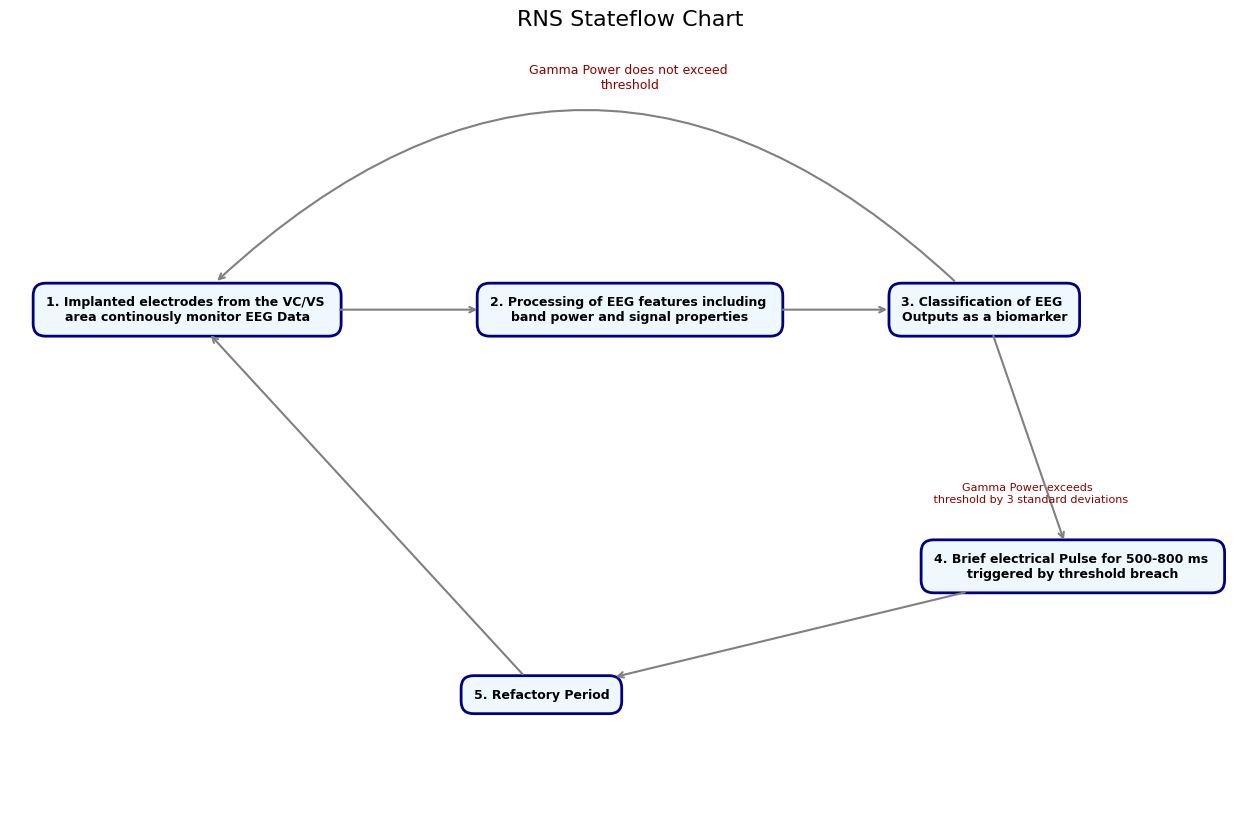

In [86]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. DATA INPUT (Your specific EEG logic)
transitions = [
    ("1. Implanted electrodes from the VC/VS \narea continously monitor EEG Data", "2. Processing of EEG features including \nband power and signal properties", ""),
    ("2. Processing of EEG features including \nband power and signal properties", "3. Classification of EEG \nOutputs as a biomarker", ""),
    ("3. Classification of EEG \nOutputs as a biomarker", "4. Brief electrical Pulse for 500-800 ms \ntriggered by threshold breach", "Gamma Power exceeds \n threshold by 3 standard deviations"),
    ("3. Classification of EEG \nOutputs as a biomarker", "1. Implanted electrodes from the VC/VS \narea continously monitor EEG Data", "Gamma Power does not exceed \nthreshold"),
    ("4. Brief electrical Pulse for 500-800 ms \ntriggered by threshold breach", "5. Refactory Period", ""),
    ("5. Refactory Period", "1. Implanted electrodes from the VC/VS \narea continously monitor EEG Data", "")
]

G = nx.DiGraph()
for src, dst, label in transitions:
    G.add_edge(src, dst, label=label)

# 2. MANUAL POSITIONING (Force a logical flow)
pos = {
    "1. Implanted electrodes from the VC/VS \narea continously monitor EEG Data": (0, 2),
    "2. Processing of EEG features including \nband power and signal properties": (5, 2),
    "3. Classification of EEG \nOutputs as a biomarker": (9, 2),
    "4. Brief electrical Pulse for 500-800 ms \ntriggered by threshold breach": (10, 0),
    "5. Refactory Period": (4, -1)
}

fig, ax = plt.subplots(figsize=(16, 10))

# 3. CUSTOM DRAWING LOOP (This creates the rectangles)
for node, (x, y) in pos.items():
    # Create a rectangle box that fits the text
    ax.text(x, y, node, ha='center', va='center', 
            bbox=dict(boxstyle='round,pad=1', facecolor='aliceblue', edgecolor='navy', linewidth=2),
            fontsize=9, fontweight='bold')

# 4. DRAW THE EDGES (Arrows)
for start, end, data in G.edges(data=True):
    # Get coordinates
    x1, y1 = pos[start]
    x2, y2 = pos[end]

    # NEW ROBUST CHECK: Look for keywords instead of the whole sentence
    is_return_to_start = ("Classification" in start and "Implanted" in end)
    is_refractory_return = ("Refactory" in start)

    # Apply curve only to the long loops back to Step 1
    if is_return_to_start:
        curve_val = 0.5  # High arch over Node 2
    else:
        curve_val = 0.0  # Perfectly straight for everything else
    
    is_one = ("Implanted" in start and "Processing" in end)
    is_two = ("Processing" in start and "Classification" in end)
    is_three_one = ("Classification" in start and "Implanted" in end)
    is_three_four = ("Classification" in start and "Brief" in end)
    is_four = ("Brief" in start and "Refactory" in end)
    is_five = ("Refactory" in start and "Implanted" in end)

    
    if is_one:
        shrink_a = 110
        shrink_b = 110
    elif is_two:
        shrink_a =110
        shrink_b = 70
    elif is_three_one:
        shrink_a = 30
        shrink_b= 30
    elif is_three_four:
        shrink_a = 20
        shrink_b= 20
    elif is_four:
        shrink_a = 80
        shrink_b= 55
    elif is_five:
        shrink_a = 20
        shrink_b= 25
        
    
    # Draw arrow (connectionstyle adds the curve for loops)
    ax.annotate("",
                xy=(x2, y2), xycoords='data',
                xytext=(x1, y1), textcoords='data',
                arrowprops=dict(arrowstyle="->", color="gray",
                                shrinkA=shrink_a, shrinkB=shrink_b, # Prevents arrow from entering the box
                                connectionstyle=f"arc3,rad={curve_val}", 
                                lw=1.5))
    
    if data['label']:
        if is_return_to_start:
            # We move the X to the middle of the arch (5.0) 
            # and the Y to the top of the curve (4.8)
            ax.text(5, 3.7, data['label'], color='darkred', 
                    fontsize=9, ha='center', va='bottom',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
        else:
            # For straight lines, we calculate the midpoint
            mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
            
            # For the pulse trigger (Node 3 to 4), the line is diagonal
            # We offset the label so it doesn't sit ON the line
            offset_y = 0.3 if y1 == y2 else -0.5 
            
            ax.text(mid_x, mid_y + offset_y, data['label'], 
                    color='darkred', fontsize=8, ha='center')

plt.axis('off')
plt.xlim(-2, 12)
plt.ylim(-2, 4)
plt.title("RNS Stateflow Chart", fontsize=16, pad=20)
plt.show()